In [1]:
#Import Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


In [2]:
# ===================== DATASET =====================
DATASET_PATH = r"C:\Users\94772\Desktop\Abdullah_project\Tamil_Character_Recognition\dataset_raw"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 24700 files belonging to 247 classes.
Using 17290 files for training.
Found 24700 files belonging to 247 classes.
Using 7410 files for validation.


In [3]:
#Split Validation & Test (FIXED)
# ===================== VAL / TEST SPLIT =====================
val_test_batches = tf.data.experimental.cardinality(val_test_ds).numpy()

val_size = val_test_batches // 2
test_size = val_test_batches - val_size

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)


In [4]:
#Get Number of Classes
NUM_CLASSES = len(train_ds.class_names)
CLASS_NAMES = train_ds.class_names

print("Number of Classes:", NUM_CLASSES)
print("Class Names:", CLASS_NAMES)


Number of Classes: 247
Class Names: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '13', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '19', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '2', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '209', '21', '210', '211', '212', '213', '214', '215', '216', '217', '218', '219', '22', '220', '221', '222', '223', '224', 

In [5]:
#Performance Optimization (IMPORTANT)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [6]:
# ===================== DATA AUGMENTATION =====================
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])


## Build MobileNetV2 Model

In [7]:
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ===================== MODEL =====================
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,                     # augmentation
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 247)            │       316,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,579,511 (9.84 MB)

 Trainable params: 318,967 (1.22 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ===================== CALLBACKS =====================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_tamil_mobilenet.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

callbacks = [early_stop, checkpoint, reduce_lr]


In [9]:
#Train the Model
# ===================== TRAIN =====================
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 384s 678ms/step - accuracy: 0.0753 - loss: 5.1073 - val_accuracy: 0.2718 - val_loss: 3.1109 - learning_rate: 0.0010
Epoch 2/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 326s 603ms/step - accuracy: 0.2603 - loss: 3.2545 - val_accuracy: 0.3464 - val_loss: 2.6891 - learning_rate: 0.0010
Epoch 3/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 330s 610ms/step - accuracy: 0.3242 - loss: 2.8434 - val_accuracy: 0.3895 - val_loss: 2.4841 - learning_rate: 0.0010
Epoch 4/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 337s 622ms/step - accuracy: 0.3566 - loss: 2.6384 - val_accuracy: 0.4019 - val_loss: 2.3716 - learning_rate: 0.0010
Epoch 5/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 339s 627ms/step - accuracy: 0.3898 - loss: 2.5008 - val_accuracy: 0.4265 - val_loss: 2.2650 - learning_rate: 0.0010
Epoch 6/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 340s 629ms/step - accuracy: 0.3988 - loss: 2.4226 - val_accuracy: 0.4467 - val_loss: 2.1929 - learning_rate: 0.0010
Epoch 7/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 343s 634ms/step - accura

In [10]:
# ===================== TEST EVALUATION =====================
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


116/116 ━━━━━━━━━━━━━━━━━━━━ 60s 495ms/step - accuracy: 0.5428 - loss: 1.7207
Test Accuracy: 54.25%
Test Loss: 1.7384


In [11]:
# ===================== SAVE MODEL =====================
model.save("Tamil_Character_MobileNetV2_Final.keras")
print("Final Model Saved Successfully!")


Final Model Saved Successfully!


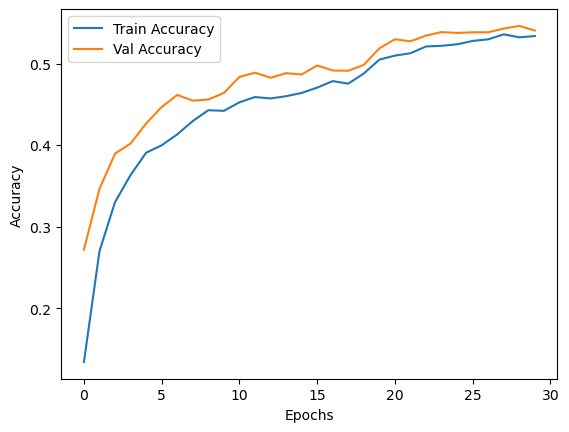

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


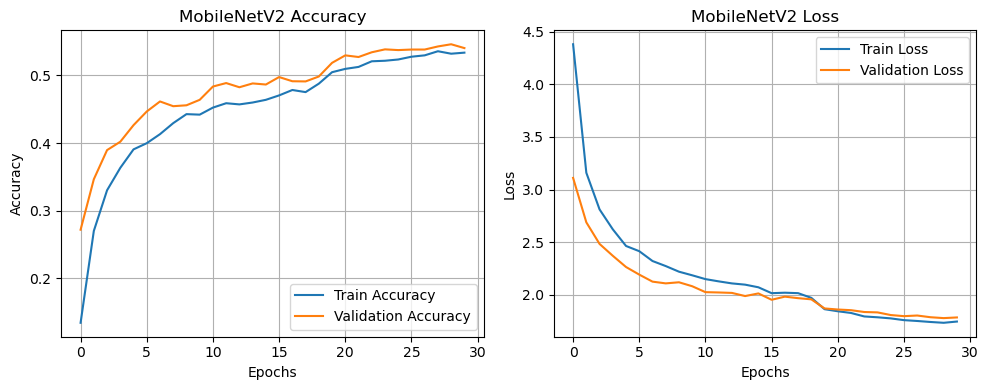

In [13]:
import matplotlib.pyplot as plt

# ===================== TRAINING CURVES =====================
plt.figure(figsize=(10, 4))

# -------- Accuracy --------
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# -------- Loss --------
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Fine-Tuning Code

In [15]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model(
    "Tamil_Character_MobileNetV2_Final.keras",
    custom_objects={"preprocess_input": preprocess_input}
)


In [16]:
# Unfreeze last 50 layers of the base model
base_model = model.layers[2]  # MobileNetV2 is the 3rd layer in your Sequential
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False


In [17]:
# Compile with a lower learning rate for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [18]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 247)            │       316,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,579,511 (9.84 MB)

 Trainable params: 2,174,071 (8.29 MB)

 Non-trainable params: 405,440 (1.55 MB)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "Best_Tamil_MobileNetV2_Finetuned.keras",  # automatically saves the best model
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
callbacks = [early_stop, reduce_lr, checkpoint]

In [20]:
EPOCHS = 30  # fine-tuning usually takes fewer epochs

history_ft = model.fit(
    train_ds,     # use datasets already loaded
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.2082 - loss: 3.8001
Epoch 1: val_accuracy improved from -inf to 0.35372, saving model to Best_Tamil_MobileNetV2_Finetuned.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 528s 945ms/step - accuracy: 0.2083 - loss: 3.7992 - val_accuracy: 0.3537 - val_loss: 3.0754 - learning_rate: 1.0000e-05
Epoch 2/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.3807 - loss: 2.4822
Epoch 2: val_accuracy improved from 0.35372 to 0.45636, saving model to Best_Tamil_MobileNetV2_Finetuned.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 480s 887ms/step - accuracy: 0.3808 - loss: 2.4819 - val_accuracy: 0.4564 - val_loss: 2.2524 - learning_rate: 1.0000e-05
Epoch 3/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.4881 - loss: 1.9301
Epoch 3: val_accuracy improved from 0.45636 to 0.52909, saving model to Best_Tamil_MobileNetV2_Finetuned.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 475s 878ms/step - accuracy: 0.4881 - loss: 1.9300 - val_accuracy: 0.5291 - val_

In [21]:
#EVALUATE 
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy after Fine-Tuning: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

116/116 ━━━━━━━━━━━━━━━━━━━━ 59s 486ms/step - accuracy: 0.8816 - loss: 0.4490
Test Accuracy after Fine-Tuning: 88.45%
Test Loss: 0.4510


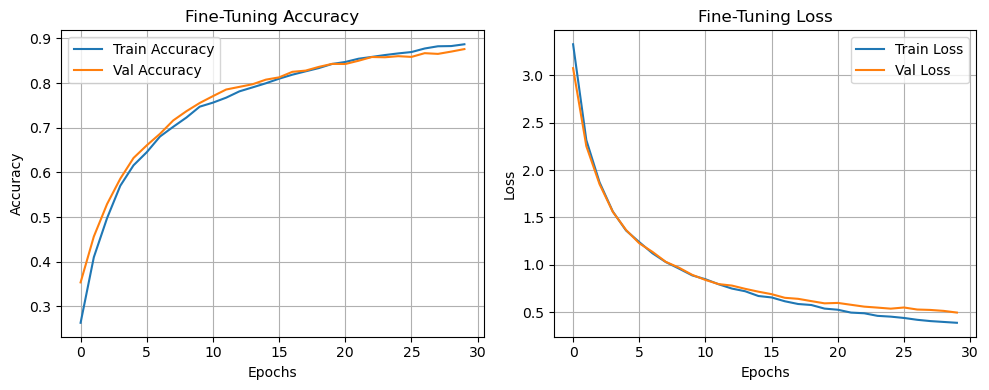

In [22]:
# ===================== PLOT TRAINING CURVES =====================
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_ft.history["accuracy"], label="Train Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="Val Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_ft.history["loss"], label="Train Loss")
plt.plot(history_ft.history["val_loss"], label="Val Loss")
plt.title("Fine-Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## fine tunning phase 2

In [23]:
print("Loading previous model...")
model = tf.keras.models.load_model(
    "Tamil_Character_MobileNetV2_Final.keras",
    custom_objects={"preprocess_input": preprocess_input}
)

Loading previous model...


In [24]:
# ===================== DATA AUGMENTATION (SAFE) =====================
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])


model.layers[1] = data_augmentation


In [26]:
# ===================== FINE-TUNING =====================
base_model = model.layers[2]  # MobileNetV2
base_model.trainable = True

# Unfreeze last 100 layers
for layer in base_model.layers[:-100]:
    layer.trainable = False

loss_fn = "sparse_categorical_crossentropy"



In [27]:
# Compile with very low LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 247)            │       316,407 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,579,511 (9.84 MB)

 Trainable params: 2,487,351 (9.49 MB)

 Non-trainable params: 92,160 (360.00 KB)

In [29]:
# ===================== CALLBACKS =====================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "Best_Tamil_MobileNetV2_Finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

In [30]:
# ===================== TRAIN =====================
EPOCHS = 30

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1094 - loss: 5.0288
Epoch 1: val_accuracy improved from -inf to 0.34833, saving model to Best_Tamil_MobileNetV2_Finetuned.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 705s 1s/step - accuracy: 0.1095 - loss: 5.0275 - val_accuracy: 0.3483 - val_loss: 2.9786 - learning_rate: 1.0000e-05
Epoch 2/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3029 - loss: 3.0171
Epoch 2: val_accuracy improved from 0.34833 to 0.42511, saving model to Best_Tamil_MobileNetV2_Finetuned.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 752s 1s/step - accuracy: 0.3030 - loss: 3.0167 - val_accuracy: 0.4251 - val_loss: 2.4772 - learning_rate: 1.0000e-05
Epoch 3/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4315 - loss: 2.2391
Epoch 3: val_accuracy improved from 0.42511 to 0.53879, saving model to Best_Tamil_MobileNetV2_Finetuned.keras
541/541 ━━━━━━━━━━━━━━━━━━━━ 754s 1s/step - accuracy: 0.4316 - loss: 2.2388 - val_accuracy: 0.5388 - val_loss: 1.7942 - lea

In [31]:
# ===================== TEST EVALUATION =====================
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

116/116 ━━━━━━━━━━━━━━━━━━━━ 61s 499ms/step - accuracy: 0.9155 - loss: 0.3179

 Test Accuracy: 91.43%
Test Loss: 0.3465


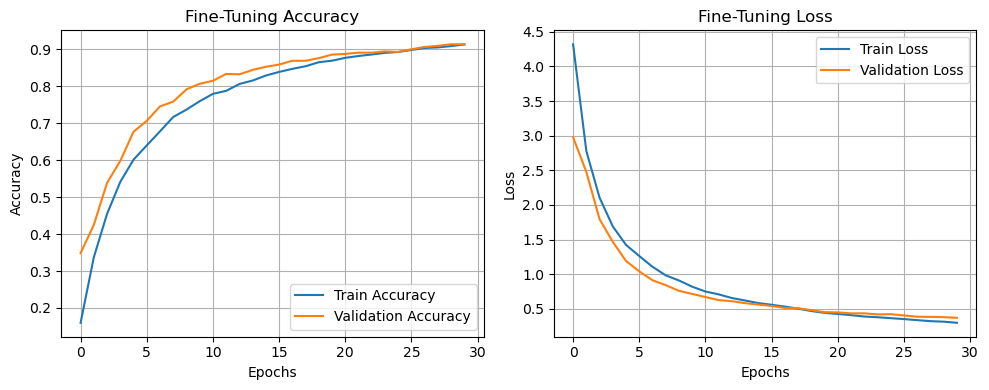

In [32]:
# ===================== TRAINING GRAPHS =====================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ft.history["accuracy"], label="Train Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="Validation Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_ft.history["loss"], label="Train Loss")
plt.plot(history_ft.history["val_loss"], label="Validation Loss")
plt.title("Fine-Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()